# 📊 Exploratory Data Analysis (EDA) & Data Pipeline Verification

In [1]:
%matplotlib inline

import os
import sys
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

sys.path.append(os.path.abspath(os.path.join('..')))

from src.dataset import LFWTripletDataset

/Users/wpasi/Desktop/siamese_project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Pipeline Configuration & Statistics

In [2]:
with open('../configs/baseline.yaml', 'r') as file:
    config = yaml.safe_load(file)

DATA_DIR = os.path.join('..', config['paths']['data_dir'])

raw_dataset = LFWTripletDataset(root_dir=DATA_DIR, transform=None)

total_identities = len(raw_dataset.all_persons)
# Individuals who can be used as Anchors (have >= 2 images)
anchor_identities = len(raw_dataset.anchor_persons)
# Discarded or Single-image identities now rescued as tough Negatives
single_image_identities = total_identities - anchor_identities

print("=========================================")
print(f"Total Unique Identities Found:  {total_identities}")
print(f"Valid Anchor Candidates (>=2):  {anchor_identities}")
print(f"Rescued Single-Image Negatives: {single_image_identities}")
print("=========================================")

Total Unique Identities Found:  5749
Valid Anchor Candidates (>=2):  1680
Rescued Single-Image Negatives: 4069


### Visualizing Data Augmentation & Triplets

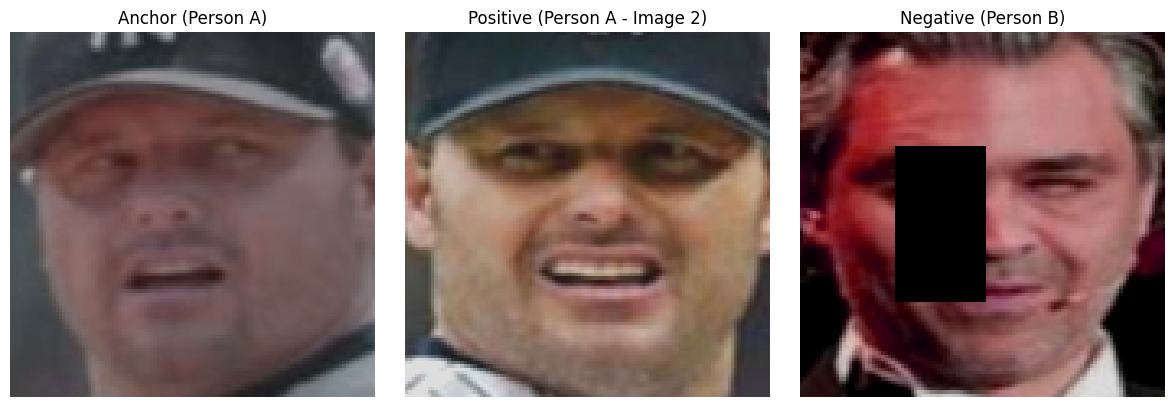

In [3]:
# Re-initialize dataset with advanced training augmentations
augmented_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), value=0),
    # Pre-calculated ImageNet stats used for standard normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = LFWTripletDataset(root_dir=DATA_DIR, transform=augmented_transform)

def imshow_tensor(tensor_img, title):
    """Helper function to denormalize and plot a PyTorch Tensor image."""
    img = tensor_img.numpy().transpose((1, 2, 0))
    # Reverse ImageNet normalization values to make the face readable for humans
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

# Fetch a random sample triplet from the dataset pipeline
anchor, positive, negative = dataset[random.randint(0, len(dataset) - 1)]

# Plotting the raw augmented inputs side by side
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
imshow_tensor(anchor, "Anchor (Person A)")

plt.subplot(1, 3, 2)
imshow_tensor(positive, "Positive (Person A - Image 2)")

plt.subplot(1, 3, 3)
imshow_tensor(negative, "Negative (Person B)")

plt.tight_layout()
plt.show()